In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

from xgboost import XGBRegressor

In [2]:
sale = pd.read_csv('EXTR_RPSale.csv', encoding='windows-1254')

C:\Users\ŞEVVAL\AppData\Local\Temp\ipykernel_2280\3006861777.py:1: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  sale = pd.read_csv('EXTR_RPSale.csv', encoding='windows-1254')


In [3]:
bldg = pd.read_csv('EXTR_ResBldg.csv')

C:\Users\ŞEVVAL\AppData\Local\Temp\ipykernel_2280\2039405476.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  bldg = pd.read_csv('EXTR_ResBldg.csv')


In [4]:
parcel = pd.read_csv('EXTR_Parcel.csv', encoding='windows-1254')

In [5]:
print(sale.shape)
print(sale.columns.tolist())

print(bldg.shape)
print(bldg.columns.tolist())

print(parcel.shape)
print(parcel.columns.tolist())

(2426893, 24)
['ExciseTaxNbr', 'Major', 'Minor', 'DocumentDate', 'SalePrice', 'RecordingNbr', 'Volume', 'Page', 'PlatNbr', 'PlatType', 'PlatLot', 'PlatBlock', 'SellerName', 'BuyerName', 'PropertyType', 'PrincipalUse', 'SaleInstrument', 'AFForestLand', 'AFCurrentUseLand', 'AFNonProfitUse', 'AFHistoricProperty', 'SaleReason', 'PropertyClass', 'SaleWarning']
(532053, 50)
['Major', 'Minor', 'BldgNbr', 'NbrLivingUnits', 'Address', 'BuildingNumber', 'Fraction', 'DirectionPrefix', 'StreetName', 'StreetType', 'DirectionSuffix', 'ZipCode', 'Stories', 'BldgGrade', 'BldgGradeVar', 'SqFt1stFloor', 'SqFtHalfFloor', 'SqFt2ndFloor', 'SqFtUpperFloor', 'SqFtUnfinFull', 'SqFtUnfinHalf', 'SqFtTotLiving', 'SqFtTotBasement', 'SqFtFinBasement', 'FinBasementGrade', 'SqFtGarageBasement', 'SqFtGarageAttached', 'DaylightBasement', 'SqFtOpenPorch', 'SqFtEnclosedPorch', 'SqFtDeck', 'HeatSystem', 'HeatSource', 'BrickStone', 'ViewUtilization', 'Bedrooms', 'BathHalfCount', 'Bath3qtrCount', 'BathFullCount', 'FpSingle

In [6]:
list(set(sale.columns) & set(bldg.columns) & set(parcel.columns))

['Minor', 'Major']

In [7]:
merged = pd.merge(sale, bldg, on=['Minor', 'Major'], how='inner').merge(parcel, on=['Minor', 'Major'], how='inner')

In [8]:
print(merged.shape)
print(merged.columns.tolist())

(1697372, 151)
['ExciseTaxNbr', 'Major', 'Minor', 'DocumentDate', 'SalePrice', 'RecordingNbr', 'Volume', 'Page', 'PlatNbr', 'PlatType', 'PlatLot_x', 'PlatBlock_x', 'SellerName', 'BuyerName', 'PropertyType', 'PrincipalUse', 'SaleInstrument', 'AFForestLand', 'AFCurrentUseLand', 'AFNonProfitUse', 'AFHistoricProperty', 'SaleReason', 'PropertyClass', 'SaleWarning', 'BldgNbr', 'NbrLivingUnits', 'Address', 'BuildingNumber', 'Fraction', 'DirectionPrefix', 'StreetName', 'StreetType', 'DirectionSuffix', 'ZipCode', 'Stories', 'BldgGrade', 'BldgGradeVar', 'SqFt1stFloor', 'SqFtHalfFloor', 'SqFt2ndFloor', 'SqFtUpperFloor', 'SqFtUnfinFull', 'SqFtUnfinHalf', 'SqFtTotLiving', 'SqFtTotBasement', 'SqFtFinBasement', 'FinBasementGrade', 'SqFtGarageBasement', 'SqFtGarageAttached', 'DaylightBasement', 'SqFtOpenPorch', 'SqFtEnclosedPorch', 'SqFtDeck', 'HeatSystem', 'HeatSource', 'BrickStone', 'ViewUtilization', 'Bedrooms', 'BathHalfCount', 'Bath3qtrCount', 'BathFullCount', 'FpSingleStory', 'FpMultiStory', 'Fp

In [9]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1697372 entries, 0 to 1697371
Columns: 151 entries, ExciseTaxNbr to OtherProblems
dtypes: bool(1), float64(5), int64(83), object(62)
memory usage: 1.9+ GB


In [10]:
merged['SalePrice'].describe()

count    1.697372e+06
mean     3.833480e+05
std      9.852499e+05
min     -4.000000e+02
25%      0.000000e+00
50%      1.839500e+05
75%      4.500000e+05
max      2.202000e+08
Name: SalePrice, dtype: float64

In [11]:
merged = merged[merged['SalePrice']>0]
print(merged.shape)
merged['SalePrice'].describe()

(1114016, 151)


count    1.114016e+06
mean     5.840887e+05
std      1.166955e+06
min      1.000000e+00
25%      1.899500e+05
50%      3.450500e+05
75%      6.350000e+05
max      2.202000e+08
Name: SalePrice, dtype: float64

In [12]:
merged['SalePrice'].quantile([0.80, 0.85, 0.90, 0.93, 0.95, 0.99, 0.999])

0.800      730000.0
0.850      852000.0
0.900     1085000.0
0.930     1330000.0
0.950     1600000.0
0.990     4352000.0
0.999    16050485.0
Name: SalePrice, dtype: float64

In [13]:
merged = merged[merged['SalePrice']<=1600000]
print(merged.shape)

(1058718, 151)


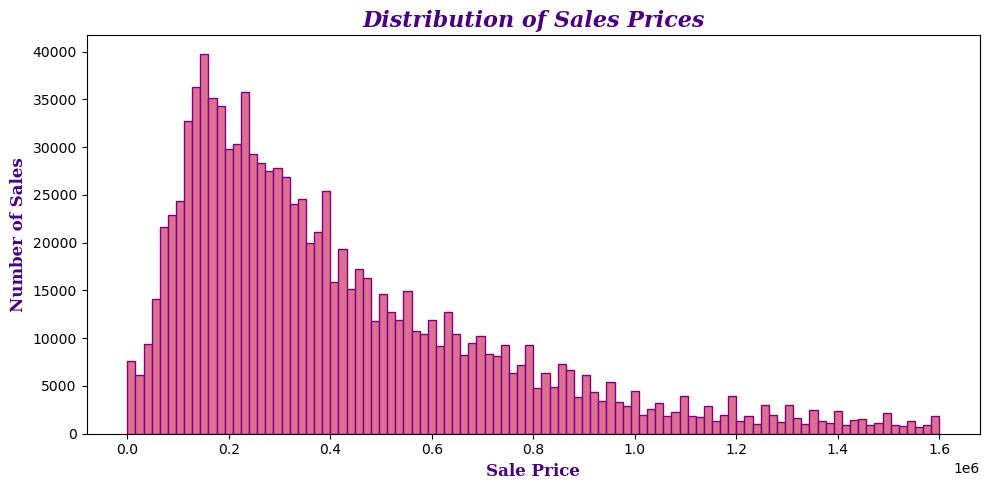

In [14]:
plt.figure(figsize=(10,5))
plt.hist(merged['SalePrice'], bins=100, color='palevioletred', edgecolor='purple')
plt.title('Distribution of Sales Prices', color='indigo', fontsize=16, fontweight='bold', fontstyle='italic', family='serif')
plt.xlabel('Sale Price', color='indigo', fontsize=12, fontweight='bold', family='serif')
plt.ylabel('Number of Sales', color='indigo', fontsize=12, fontweight='bold', family='serif')
plt.tight_layout()
plt.show()

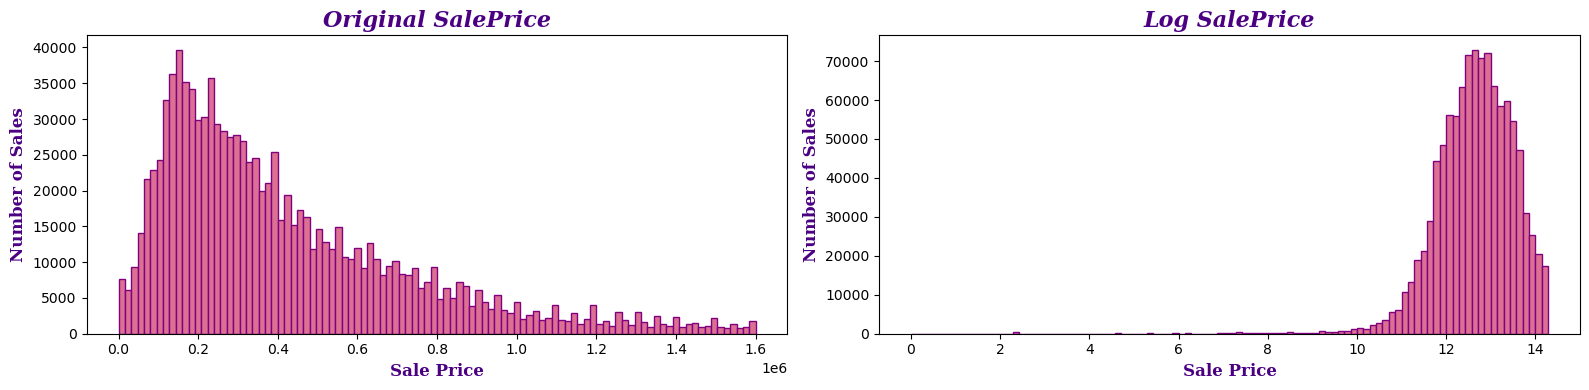

In [15]:
merged['SalePrice_log'] = np.log(merged['SalePrice'])
fig, axes = plt.subplots(1, 2, figsize=(16,4))
axes[0].hist(merged['SalePrice'], bins=100, color='palevioletred', edgecolor='purple')
axes[0].set_title('Original SalePrice', color='indigo', fontsize=16, fontweight='bold', fontstyle='italic', family='serif')
axes[0].set_xlabel('Sale Price', color='indigo', fontsize=12, fontweight='bold', family='serif')
axes[0].set_ylabel('Number of Sales', color='indigo', fontsize=12, fontweight='bold', family='serif')
axes[1].hist(merged['SalePrice_log'], bins=100, color='palevioletred', edgecolor='purple')
axes[1].set_title('Log SalePrice', color='indigo', fontsize=16, fontweight='bold', fontstyle='italic', family='serif')
axes[1].set_xlabel('Sale Price', color='indigo', fontsize=12, fontweight='bold', family='serif')
axes[1].set_ylabel('Number of Sales', color='indigo', fontsize=12, fontweight='bold', family='serif')
plt.tight_layout()
plt.show()

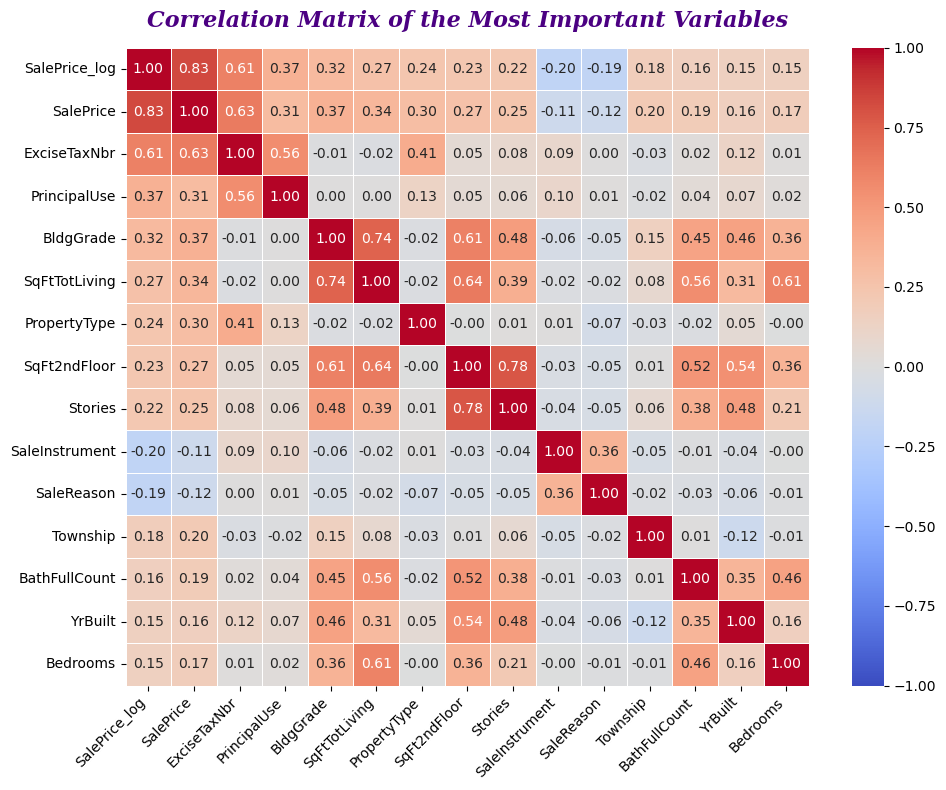

In [16]:
numeric_merged = merged.select_dtypes(include=["int64", "float64"])
all_corr = numeric_merged.corr()
top_features = all_corr["SalePrice_log"].abs().sort_values(ascending=False).head(15).index
filtered_corr = numeric_merged[top_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of the Most Important Variables", color='indigo', fontsize=16, fontweight='bold', fontstyle='italic', family='serif', pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
features = [
    'SalePrice_log',
    'SqFtTotLiving',
    'BldgGrade',
    'PrincipalUse',
    'YrBuilt',
    'Bedrooms',
    'PropertyType',
    'Bath3qtrCount',
    'SqFtLot',
    'WfntLocation',
    'MtRainier',
    'SeattleSkyline',
    'PugetSound',
    'Township'
]
model = merged[features]
model.describe()

,SalePrice_log,SqFtTotLiving,BldgGrade,PrincipalUse,YrBuilt,Bedrooms,PropertyType,Bath3qtrCount,SqFtLot,WfntLocation,MtRainier,SeattleSkyline,PugetSound,Township
count,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06,1.058718e+06
mean,1.263667e+01,2.136198e+03,7.653445e+00,5.179613e+00,1.973790e+03,3.437047e+00,4.308356e+00,5.098459e-01,2.279928e+04,1.028036e-01,2.121528e-02,1.803219e-02,5.998481e-02,2.381072e+01
std,9.118231e-01,9.347031e+02,1.150549e+00,2.081763e+00,3.012590e+01,9.775247e-01,5.439135e+00,6.578669e-01,3.499994e+05,8.686222e-01,2.385916e-01,2.203879e-01,4.008761e-01,1.660389e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.894000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01
25%,1.211724e+01,1.470000e+03,7.000000e+00,6.000000e+00,1.953000e+03,3.000000e+00,3.000000e+00,0.000000e+00,5.208000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.300000e+01
50%,1.269673e+01,1.980000e+03,7.000000e+00,6.000000e+00,1.978000e+03,3.000000e+00,3.000000e+00,0.000000e+00,7.700000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01
75%,1.326213e+01,2.620000e+03,8.000000e+00,6.000000e+00,1.998000e+03,4.000000e+00,3.000000e+00,1.000000e+00,1.082900e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+01
max,1.428551e+01,4.816000e+04,2.000000e+01,1.100000e+01,2.026000e+03,5.400000e+01,9.900000e+01,1.600000e+01,2.330525e+07,9.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,2.600000e+01


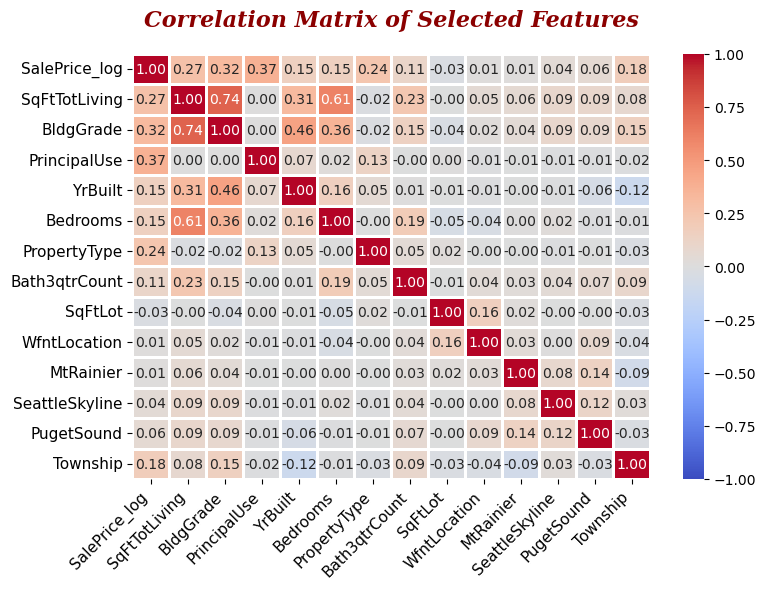

In [18]:
select_corr = model.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(select_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.8, annot_kws={"size": 10},)
plt.title("Correlation Matrix of Selected Features", fontsize=16, fontweight="bold", color="darkred", fontstyle='italic', family='serif', pad=20)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

In [85]:
model['Bedrooms'].value_counts().sort_index()

Bedrooms
0       2301
1      15271
2     114718
3     455672
4     358937
5      90714
6      15212
7       2693
8       2244
9        495
10       214
11        91
12       109
13        23
14         8
15         3
16         4
20         3
24         2
54         4
Name: count, dtype: int64

In [20]:
model = model[model['SqFtTotLiving']>0]
model = model[model['Bedrooms']<=12]
model = model[model['Bedrooms']>0]
model = model[model['BldgGrade']>0]
model = model[model['SalePrice_log']>0]
model.shape

(1056338, 14)

In [21]:
model.describe()

,SalePrice_log,SqFtTotLiving,BldgGrade,PrincipalUse,YrBuilt,Bedrooms,PropertyType,Bath3qtrCount,SqFtLot,WfntLocation,MtRainier,SeattleSkyline,PugetSound,Township
count,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06,1.056338e+06
mean,1.263756e+01,2.139036e+03,7.656732e+00,5.179274e+00,1.973774e+03,3.443891e+00,4.306664e+00,5.097715e-01,1.770074e+04,9.990552e-02,2.121669e-02,1.803400e-02,5.989560e-02,2.381022e+01
std,9.092284e-01,9.322595e+02,1.147161e+00,2.081910e+00,3.011322e+01,9.574854e-01,5.420887e+00,6.570006e-01,6.477899e+04,8.546477e-01,2.385946e-01,2.204079e-01,4.005044e-01,1.660388e+00
min,6.931472e-01,7.000000e+01,1.000000e+00,0.000000e+00,1.894000e+03,1.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01
25%,1.211997e+01,1.480000e+03,7.000000e+00,6.000000e+00,1.954000e+03,3.000000e+00,3.000000e+00,0.000000e+00,5.206000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.300000e+01
50%,1.269772e+01,1.980000e+03,7.000000e+00,6.000000e+00,1.978000e+03,3.000000e+00,3.000000e+00,0.000000e+00,7.700000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01
75%,1.326213e+01,2.620000e+03,8.000000e+00,6.000000e+00,1.998000e+03,4.000000e+00,3.000000e+00,1.000000e+00,1.082200e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+01
max,1.428551e+01,4.816000e+04,2.000000e+01,1.100000e+01,2.026000e+03,1.200000e+01,9.900000e+01,1.200000e+01,7.039596e+06,9.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,2.600000e+01


In [22]:
X = model.drop(columns=['SalePrice_log'])
y = model['SalePrice_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print('R^2:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R^2: 0.3088298926944132
MAE: 0.4972232799505544


In [27]:
xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print('R^2:', r2_score(y_test, y_pred_xgb))
print('MAE:', mean_absolute_error(y_test, y_pred_xgb))

R^2: 0.5074845426549123
MAE: 0.3833925834433966


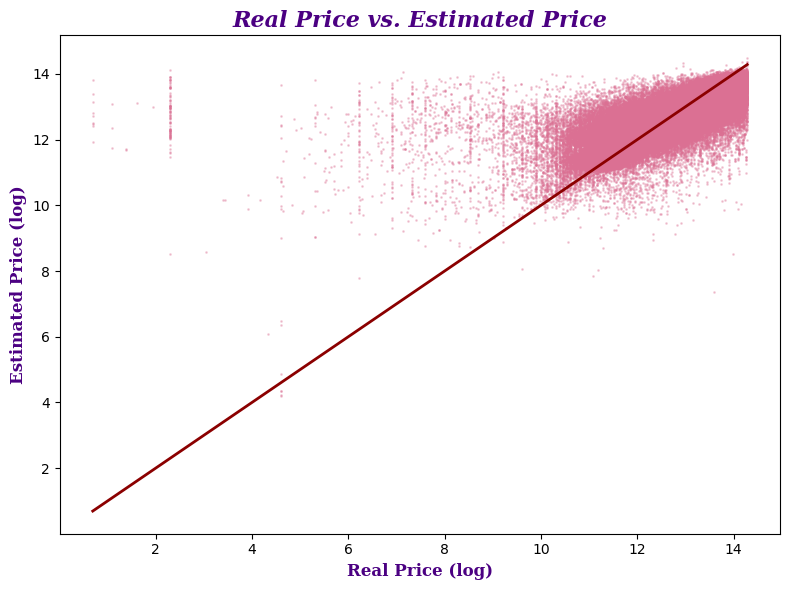

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color="palevioletred", s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="darkred", linewidth=2)
plt.xlabel("Real Price (log)", color='indigo', fontsize=12, fontweight='bold', family='serif')
plt.ylabel("Estimated Price (log)",  color='indigo', fontsize=12, fontweight='bold', family='serif')
plt.title("Real Price vs. Estimated Price", color='indigo', fontsize=16, fontweight='bold', fontstyle='italic', family='serif')
plt.tight_layout()
plt.show()

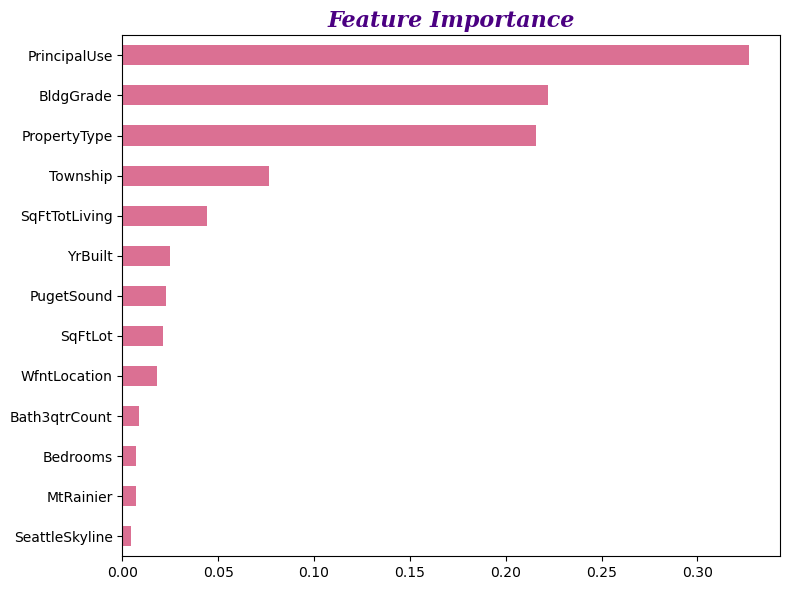

In [29]:
importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind="barh", color="palevioletred", figsize=(8, 6))
plt.title("Feature Importance", color='indigo', fontsize=16, fontweight='bold', fontstyle='italic', family='serif')
plt.tight_layout()
plt.show()